<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Impact-ML/blob/main/01_Data_Extraction_and_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# Mount Google Drive to access my project workspace
drive.mount('/content/drive')

# WARNING: Change the path below to your own Google Drive folder if you are cloning this repo
# Define the path to my main project directory
project_folder = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'

# Set the current working directory for the upcoming operations
os.chdir(project_folder)
print(f"Working directory successfully set to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory successfully set to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


In [8]:
# Install the necessary libraries for the EEG processing pipeline
!pip install mne pandas numpy scikit-learn awscli

import os

# Define the dataset directory
dataset_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
os.makedirs(dataset_dir, exist_ok=True)

print("Initiating raw EEG dataset synchronization via AWS S3...")

# Utilizing AWS CLI for direct, fail-safe synchronization with OpenNeuro's Amazon S3 buckets
!aws s3 sync --no-sign-request s3://openneuro.org/ds003774 /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data

print("Dataset synchronization completed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
Initiating raw EEG dataset synchronization via AWS S3...
download: s3://openneuro.org/ds003774/CHANGES to ds00377

Visualizing raw EEG signal for data quality inspection...
Successfully located file: sub-001_task-ListeningandResponse_eeg.set

--- DATASET METADATA ---
Total Channels: 129
Sampling Rate: 250.0 Hz
Recording Length: 2003.65 seconds

Rendering signal visualization...
Using matplotlib as 2D backend.


/tmp/ipykernel_15241/653411282.py:21: RuntimeWarning: Limited 5 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)
/tmp/ipykernel_15241/653411282.py:21: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)


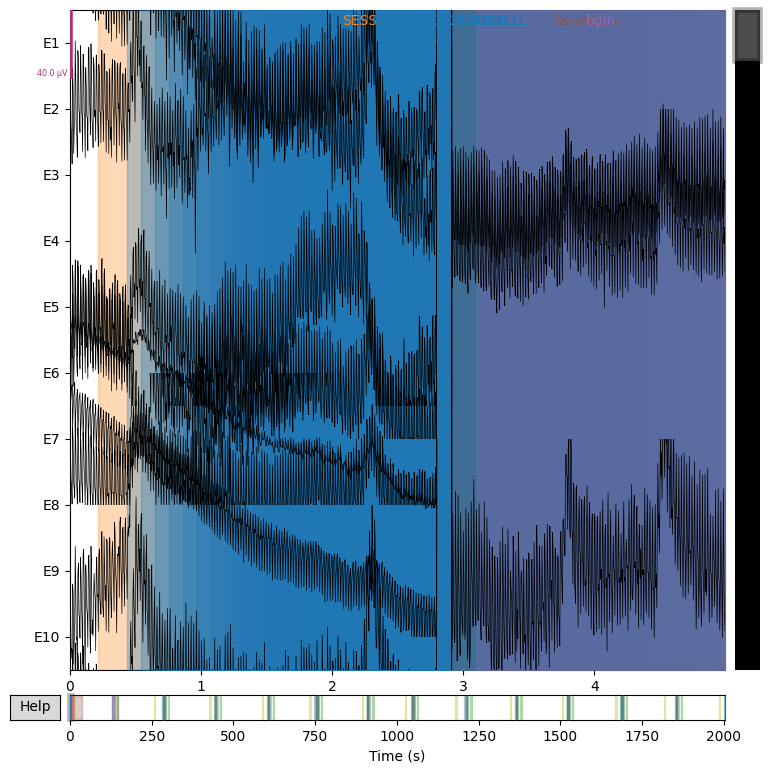

In [9]:
import os
import glob
import mne
import matplotlib.pyplot as plt

# Define the path to the synchronized dataset
dataset_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

print("Visualizing raw EEG signal for data quality inspection...")

# Dynamically locate the first available .set file
eeg_files = sorted(glob.glob(os.path.join(dataset_dir, '**', '*.set'), recursive=True))

if eeg_files:
    sample_file = eeg_files[0]
    print(f"Successfully located file: {os.path.basename(sample_file)}")

    try:
        # Load the raw EEG data using EEGLAB reader.
        # AWS sync ensures the missing .fdt files are now present!
        raw = mne.io.read_raw_eeglab(sample_file, preload=True)

        # Output metadata for the report
        print("\n--- DATASET METADATA ---")
        print(f"Total Channels: {raw.info['nchan']}")
        print(f"Sampling Rate: {raw.info['sfreq']} Hz")
        print(f"Recording Length: {raw.times[-1]:.2f} seconds")

        # Plot the first 5 seconds of the signal
        print("\nRendering signal visualization...")
        fig = raw.plot(duration=5, n_channels=10, show=False, title="Raw EEG Inspection - AWS Synced Data")
        plt.show()
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print("Could not locate standard EEG files.")

### Exploratory Data Analysis (EDA) & Data Overview
Based on the initial inspection of the sample subject (sub-001), the structural properties of our data are confirmed:

* **Electrodes (Features):** 129 Channels (Indicating a High-Density EEG cap was used).
* **Temporal Resolution:** 250.0 Hz (The device captures 250 voltage measurements per second, providing excellent digital resolution for accurate frequency extraction).
* **Session Length:** ~33 minutes (2003.65 seconds) of continuous recording per run for each subject.
* **Signal Quality & Visualization:** Time-domain visualization confirms active signal capture. Note: The visual plot renders only a 5-second epoch across 10 channels to ensure visual clarity and prevent rendering clutter; the underlying data remains fully intact in memory. The presence of boundary events in the metadata indicates natural experimental pauses, typical of robust real-world physiological recordings.